# 05 - Model Training

## Objective

The goal of this notebook is to build machine learning models that predict whether a customer is likely to churn.

The modeling workflow will include:

- Defining features and target
- Train/test splitting with stratification
- Building a preprocessing pipeline
- Training a Logistic Regression baseline
- Comparing multiple classification models
- Investigating class imbalance
- Performing reasonable hyperparameter tuning

All preprocessing steps will be fitted only on the training data to prevent data leakage.

In [41]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

In [42]:
df = pd.read_csv(
    "../data/processed/telco_churn_engineered.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag,TenureGroup,TotalServices
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12 months,2
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,0,25-48 months,4
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12 months,4
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48 months,4
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12 months,2


In [43]:
df.shape

(7043, 24)

## Defining Features and Target

The binary `ChurnFlag` column is used as the prediction target:

- `0` = Customer did not churn
- `1` = Customer churned

The following columns are excluded from the predictive features:

- `customerID`: unique identifier with no meaningful predictive behavior
- `Churn`: original target represented as Yes/No
- `ChurnFlag`: numerical target variable

Removing both versions of the target prevents target leakage.

In [44]:
X = df.drop(
    columns=[
        "customerID",
        "Churn",
        "ChurnFlag"
    ]
)

y = df["ChurnFlag"]

In [45]:
X.shape, y.shape

((7043, 21), (7043,))

In [46]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'TenureGroup', 'TotalServices'],
      dtype='str')

In [47]:
y.value_counts()

ChurnFlag
0    5174
1    1869
Name: count, dtype: int64

## Train/Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used for training.
- 20% is reserved for final testing.
- `stratify=y` is used because the churn classes are imbalanced.

Stratification ensures that the proportion of churned and non-churned customers remains approximately the same in both the training and testing datasets.

A fixed `random_state` is used to make the results reproducible.

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [49]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5634, 21)
Testing features: (1409, 21)
Training target: (5634,)
Testing target: (1409,)


In [50]:
print("Full dataset:")
print(y.value_counts(normalize=True))

print("\nTraining dataset:")
print(y_train.value_counts(normalize=True))

print("\nTesting dataset:")
print(y_test.value_counts(normalize=True))

Full dataset:
ChurnFlag
0    0.73463
1    0.26537
Name: proportion, dtype: float64

Training dataset:
ChurnFlag
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing dataset:
ChurnFlag
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [51]:
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "TotalServices"
]

In [52]:
categorical_features = [
    col for col in X.columns
    if col not in numerical_features
]

In [53]:
print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices']

Categorical Features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


## Preprocessing Pipeline

The dataset contains both numerical and categorical features, so different preprocessing steps are required.

### Numerical Features

For numerical variables:

- Missing values are handled using median imputation.
- Features are standardized using `StandardScaler`.

### Categorical Features

For categorical variables:

- Missing values are handled using the most frequent category.
- Categories are converted into numerical form using `OneHotEncoder`.
- `handle_unknown="ignore"` ensures that previously unseen categories in future data do not cause prediction errors.

A `ColumnTransformer` is used to apply these transformations to the appropriate columns.

The preprocessing steps are placed inside a Scikit-learn `Pipeline` so that they are fitted only on the training data, preventing data leakage.

In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [55]:
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "TotalServices"
]

In [56]:
categorical_features = [
    col for col in X.columns
    if col not in numerical_features
]

In [57]:
print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices']

Categorical Features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


In [58]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [59]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [60]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

## Baseline Model - Logistic Regression

Logistic Regression is used as the baseline model because:

- It is simple and interpretable.
- It works well for binary classification.
- It provides predicted probabilities.
- Its coefficients can later help explain which features influence churn predictions.

More complex models will later be compared against this baseline.

In [61]:
from sklearn.linear_model import LogisticRegression

In [62]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [63]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['gender','SeniorCitizen','Partner',...,'TotalCharges','TenureGroup', 'TotalServices']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

In [64]:
y_pred = logistic_model.predict(X_test)

In [65]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [66]:
y_prob[:10]

array([0.04190399, 0.73414884, 0.05190477, 0.33590218, 0.02491442,
       0.54365311, 0.38216279, 0.10844708, 0.00495729, 0.31564838])

## Baseline Model Evaluation

The Logistic Regression model is evaluated using several classification metrics.

Accuracy alone is not sufficient because the target classes are moderately imbalanced.

The following metrics are considered:

- **Accuracy**: Overall percentage of correct predictions.
- **Precision**: Among customers predicted to churn, how many actually churned.
- **Recall**: Among customers who actually churned, how many were successfully identified.
- **F1-score**: Balance between precision and recall.
- **ROC-AUC**: Measures the model's ability to distinguish churners from non-churners across different probability thresholds.

In [67]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [68]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Accuracy  : 0.7991
Precision : 0.6522
Recall    : 0.5214
F1-score  : 0.5795
ROC-AUC   : 0.8425


In [69]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [70]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[931, 104],
       [179, 195]])

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

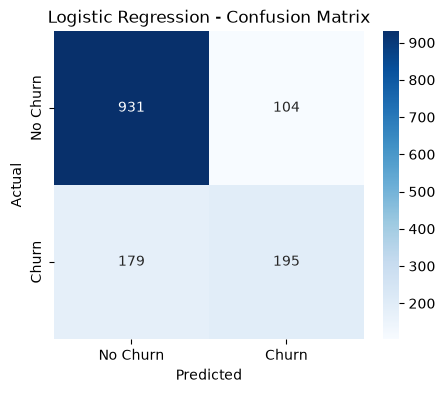

In [72]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Logistic Regression Baseline Results

The Logistic Regression baseline achieved:

- Accuracy: **79.9%**
- Precision: **65.2%**
- Recall: **52.1%**
- F1-score: **58.0%**
- ROC-AUC: **84.3%**

The model performs well at distinguishing higher-risk from lower-risk customers overall, as indicated by the ROC-AUC score.

However, recall for the churn class is only approximately 52%. This means that the model misses a substantial number of customers who actually churn.

From a business perspective, false negatives are important because these customers would not be identified for possible retention actions.

Therefore, later model comparison should consider recall, F1-score, and ROC-AUC rather than choosing a model based only on accuracy.

## Model Comparison

Several classification algorithms are compared using the same training and testing data.

The goal is not to select a model based only on accuracy. Each model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

This allows us to compare predictive performance while considering the business importance of identifying actual churners.

In [73]:
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [74]:
def evaluate_model(name, model):
    pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    pred = pipeline.predict(X_test)
    prob = pipeline.predict_proba(X_test)[:, 1]

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob)
    }

    return pipeline, result

In [75]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [76]:
results = []
trained_models = {}

for name, model in models.items():
    pipeline, result = evaluate_model(name, model)

    trained_models[name] = pipeline
    results.append(result)

In [77]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.799148,0.652174,0.521390,0.579495,0.842460
1,Decision Tree,0.728886,0.489950,0.521390,0.505181,0.662396
2,Random Forest,0.777857,0.604096,0.473262,0.530735,0.821027
3,Gradient Boosting,0.805536,0.674825,0.516043,0.584848,0.842817


In [78]:
results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Gradient Boosting,0.805536,0.674825,0.516043,0.584848,0.842817
1,Logistic Regression,0.799148,0.652174,0.521390,0.579495,0.842460
2,Random Forest,0.777857,0.604096,0.473262,0.530735,0.821027
3,Decision Tree,0.728886,0.489950,0.521390,0.505181,0.662396


In [79]:
display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Gradient Boosting,0.8055,0.6748,0.5160,0.5848,0.8428
1,Logistic Regression,0.7991,0.6522,0.5214,0.5795,0.8425
2,Random Forest,0.7779,0.6041,0.4733,0.5307,0.8210
3,Decision Tree,0.7289,0.4899,0.5214,0.5052,0.6624


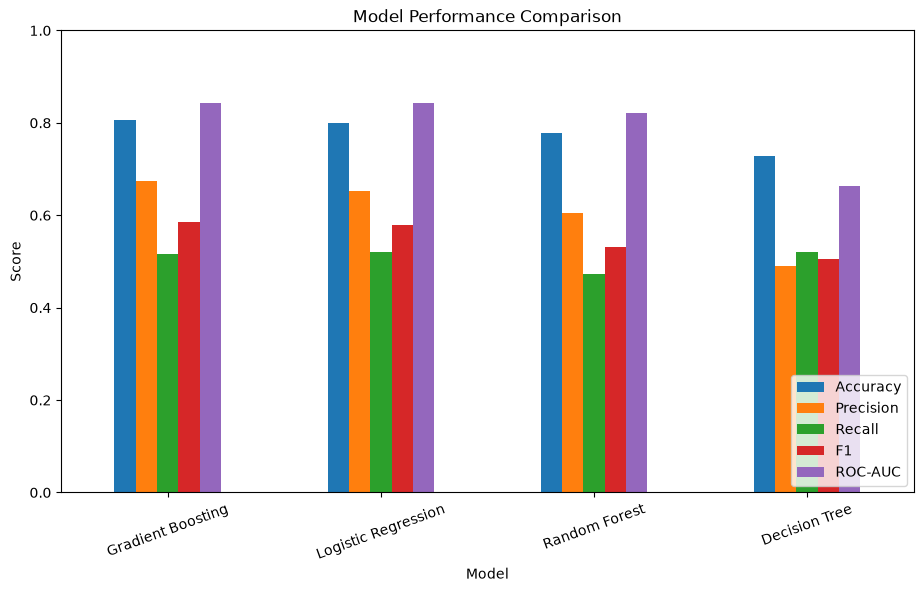

In [80]:
plot_df = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
]

plot_df.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")

plt.show()

### Initial Model Comparison

The untuned models show several important differences:

- Gradient Boosting achieved the highest accuracy, precision, F1-score, and ROC-AUC.
- Logistic Regression performed almost as well as Gradient Boosting and achieved slightly higher recall.
- Random Forest performed reasonably well but had lower recall and ROC-AUC than Logistic Regression and Gradient Boosting.
- The Decision Tree performed the worst overall, particularly in precision and ROC-AUC.

Gradient Boosting and Logistic Regression currently appear to be the strongest candidates.

However, recall remains close to 52% for both models. This means that almost half of the customers who actually churn are still being missed.

Because churn is moderately imbalanced, the next step is to investigate whether class imbalance handling can improve the detection of churned customers.

No final model is selected at this stage.

## Handling Class Imbalance

The dataset contains approximately 73.5% non-churn customers and 26.5% churn customers.

This imbalance is moderate rather than extreme. However, the baseline models identify only around half of the actual churners.

Therefore, class weighting is tested to determine whether giving greater importance to the minority churn class improves recall.

Class weighting does not create synthetic observations. Instead, mistakes involving minority-class examples receive a larger penalty during training.

In [81]:
balanced_logistic = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [82]:
balanced_log_pipeline, balanced_log_result = evaluate_model(
    "Logistic Regression Balanced",
    balanced_logistic
)

balanced_log_result

{'Model': 'Logistic Regression Balanced',
 'Accuracy': 0.7331440738112136,
 'Precision': 0.4983164983164983,
 'Recall': 0.7914438502673797,
 'F1': 0.6115702479338843,
 'ROC-AUC': 0.8421710713270816}

In [83]:
balanced_tree = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

balanced_tree_pipeline, balanced_tree_result = evaluate_model(
    "Decision Tree Balanced",
    balanced_tree
)

In [84]:
balanced_forest = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

balanced_forest_pipeline, balanced_forest_result = evaluate_model(
    "Random Forest Balanced",
    balanced_forest
)

In [85]:
imbalance_results = pd.DataFrame([
    results_df.loc[
        results_df["Model"] == "Logistic Regression"
    ].iloc[0].to_dict(),

    balanced_log_result,

    results_df.loc[
        results_df["Model"] == "Random Forest"
    ].iloc[0].to_dict(),

    balanced_forest_result,

    results_df.loc[
        results_df["Model"] == "Decision Tree"
    ].iloc[0].to_dict(),

    balanced_tree_result
])

imbalance_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.799148,0.652174,0.521390,0.579495,0.842460
1,Logistic Regression Balanced,0.733144,0.498316,0.791444,0.611570,0.842171
2,Random Forest,0.777857,0.604096,0.473262,0.530735,0.821027
3,Random Forest Balanced,0.762952,0.546729,0.625668,0.583541,0.819994
4,Decision Tree,0.728886,0.489950,0.521390,0.505181,0.662396
5,Decision Tree Balanced,0.741661,0.513812,0.497326,0.505435,0.663879


In [86]:
display(
    imbalance_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.7991,0.6522,0.5214,0.5795,0.8425
1,Logistic Regression Balanced,0.7331,0.4983,0.7914,0.6116,0.8422
2,Random Forest,0.7779,0.6041,0.4733,0.5307,0.8210
3,Random Forest Balanced,0.7630,0.5467,0.6257,0.5835,0.8200
4,Decision Tree,0.7289,0.4899,0.5214,0.5052,0.6624
5,Decision Tree Balanced,0.7417,0.5138,0.4973,0.5054,0.6639


### Impact of Class Weighting

Class weighting had the largest impact on Logistic Regression.

The standard Logistic Regression model achieved approximately 52.1% recall, while the balanced version increased recall to approximately 79.1%.

This means that the balanced model identifies substantially more customers who actually churn.

However, this improvement comes with a trade-off:

- Accuracy decreased from approximately 79.9% to 73.3%.
- Precision decreased from approximately 65.2% to 49.8%.
- More non-churning customers are therefore incorrectly classified as potential churners.

Interestingly, ROC-AUC remained almost unchanged at approximately 0.84. This suggests that the model's overall ability to rank high-risk customers remains similar, while class weighting changes how aggressively customers are classified as churners.

For a retention use case, the balanced Logistic Regression model may be useful when missing an actual churner is considered more expensive than contacting an additional non-churning customer.

In [87]:
balanced_pred = balanced_log_pipeline.predict(X_test)

balanced_cm = confusion_matrix(
    y_test,
    balanced_pred
)

balanced_cm

array([[737, 298],
       [ 78, 296]])

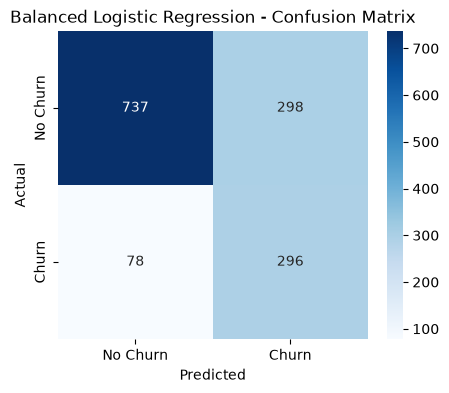

In [88]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    balanced_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Balanced Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Why SMOTE Was Not Immediately Applied

The dataset has moderate rather than extreme class imbalance.

Class weighting already produced a substantial improvement in churn recall without modifying the training dataset or generating synthetic observations.

Therefore, class weighting was preferred as the first imbalance-handling technique.

SMOTE could still be tested as an additional experiment, but it should only be applied to training data and care must be taken with categorical variables.

In [89]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold

## Hyperparameter Tuning

The initial model comparison identified two strong candidates:

- Balanced Logistic Regression
- Gradient Boosting

Hyperparameter tuning is performed only on these models to avoid unnecessary computation and overfitting.

Cross-validation is used so that model settings are evaluated across multiple training subsets rather than a single split.

ROC-AUC is used as the primary tuning metric because it evaluates how well the model separates churners from non-churners across different classification thresholds.

The final tuned models will still be evaluated using accuracy, precision, recall, F1-score, and ROC-AUC on the untouched test set.

In [90]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [91]:
balanced_log_pipeline_tune = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [92]:
log_param_grid = {
    "model__C": [0.01, 0.1, 1, 10]
}

In [93]:
log_grid = GridSearchCV(
    estimator=balanced_log_pipeline_tune,
    param_grid=log_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

In [94]:
log_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informat

In [95]:
print("Best Parameters:")
print(log_grid.best_params_)

print("\nBest CV ROC-AUC:")
print(log_grid.best_score_)

Best Parameters:
{'model__C': 1}

Best CV ROC-AUC:
0.8463015666679581


In [96]:
best_log_model = log_grid.best_estimator_

log_tuned_pred = best_log_model.predict(X_test)
log_tuned_prob = best_log_model.predict_proba(X_test)[:, 1]

In [97]:
log_tuned_result = {
    "Model": "Tuned Balanced Logistic Regression",
    "Accuracy": accuracy_score(y_test, log_tuned_pred),
    "Precision": precision_score(y_test, log_tuned_pred),
    "Recall": recall_score(y_test, log_tuned_pred),
    "F1": f1_score(y_test, log_tuned_pred),
    "ROC-AUC": roc_auc_score(y_test, log_tuned_prob)
}

log_tuned_result

{'Model': 'Tuned Balanced Logistic Regression',
 'Accuracy': 0.7331440738112136,
 'Precision': 0.4983164983164983,
 'Recall': 0.7914438502673797,
 'F1': 0.6115702479338843,
 'ROC-AUC': 0.8421710713270816}

### Gradient Boosting Tuning

Gradient Boosting has several important hyperparameters.

RandomizedSearchCV is used instead of an exhaustive grid search to test a reasonable number of combinations while keeping computation manageable.

In [98]:
gb_pipeline_tune = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ]
)

In [99]:
gb_param_grid = {
    "model__n_estimators": [50, 100, 150, 200],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [1, 2, 3, 4],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.8, 1.0]
}

In [100]:
gb_random = RandomizedSearchCV(
    estimator=gb_pipeline_tune,
    param_distributions=gb_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

In [101]:
gb_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [1, 2, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predi

In [102]:
print("Best Parameters:")
print(gb_random.best_params_)

print("\nBest CV ROC-AUC:")
print(gb_random.best_score_)

Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_depth': 3, 'model__learning_rate': 0.03}

Best CV ROC-AUC:
0.8507389898871967


In [103]:
best_gb_model = gb_random.best_estimator_

gb_tuned_pred = best_gb_model.predict(X_test)
gb_tuned_prob = best_gb_model.predict_proba(X_test)[:, 1]

In [104]:
gb_tuned_result = {
    "Model": "Tuned Gradient Boosting",
    "Accuracy": accuracy_score(y_test, gb_tuned_pred),
    "Precision": precision_score(y_test, gb_tuned_pred),
    "Recall": recall_score(y_test, gb_tuned_pred),
    "F1": f1_score(y_test, gb_tuned_pred),
    "ROC-AUC": roc_auc_score(y_test, gb_tuned_prob)
}

gb_tuned_result

{'Model': 'Tuned Gradient Boosting',
 'Accuracy': 0.8041163946061036,
 'Precision': 0.6701388888888888,
 'Recall': 0.516042780748663,
 'F1': 0.5830815709969789,
 'ROC-AUC': 0.8472112428634168}

In [105]:
tuning_comparison = pd.DataFrame([
    balanced_log_result,
    log_tuned_result,
    results_df[
        results_df["Model"] == "Gradient Boosting"
    ].iloc[0].to_dict(),
    gb_tuned_result
])

tuning_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression Balanced,0.733144,0.498316,0.791444,0.611570,0.842171
1,Tuned Balanced Logistic Regression,0.733144,0.498316,0.791444,0.611570,0.842171
2,Gradient Boosting,0.805536,0.674825,0.516043,0.584848,0.842817
3,Tuned Gradient Boosting,0.804116,0.670139,0.516043,0.583082,0.847211


In [106]:
display(
    tuning_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression Balanced,0.7331,0.4983,0.7914,0.6116,0.8422
1,Tuned Balanced Logistic Regression,0.7331,0.4983,0.7914,0.6116,0.8422
2,Gradient Boosting,0.8055,0.6748,0.5160,0.5848,0.8428
3,Tuned Gradient Boosting,0.8041,0.6701,0.5160,0.5831,0.8472


### Hyperparameter Tuning Results

Hyperparameter tuning produced different outcomes for the two candidate models.

#### Balanced Logistic Regression

Tuning did not materially change the test-set performance of Balanced Logistic Regression.

Its main strength remains its high churn recall of approximately **79.1%**, meaning it successfully identifies a large proportion of actual churners.

#### Gradient Boosting

Tuning slightly improved Gradient Boosting's ROC-AUC from approximately **0.8428** to **0.8472**.

The tuned model achieved:

- Accuracy: approximately **80.4%**
- Precision: approximately **67.0%**
- Recall: approximately **51.6%**
- F1-score: approximately **58.3%**
- ROC-AUC: approximately **84.7%**

The improvement from tuning is modest, which is expected for a relatively small and structured dataset.

At this stage, no single model is considered universally best.

- Balanced Logistic Regression is stronger when identifying as many churners as possible is the priority.
- Tuned Gradient Boosting provides stronger overall classification performance and the highest ROC-AUC.

The final model decision should therefore consider the business cost of false positives and false negatives.

# Modeling Summary

The modeling stage compared multiple classification algorithms under the same preprocessing and train/test split.

Key observations:

- Logistic Regression provided a strong and interpretable baseline.
- Decision Tree showed weaker generalization performance.
- Random Forest performed better than a single Decision Tree but remained behind the strongest models.
- Gradient Boosting achieved the strongest overall ROC-AUC.
- Class weighting significantly improved Logistic Regression recall from approximately 52% to 79%.
- Hyperparameter tuning slightly improved Gradient Boosting's ROC-AUC.

Two models are therefore carried forward for final evaluation:

1. **Tuned Gradient Boosting** — strongest overall discrimination.
2. **Balanced Logistic Regression** — strongest churn recall.

The next stage will compare these models in greater detail, interpret their predictions, and determine how predicted probabilities can be used for customer risk segmentation.